In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("clean_data (1).csv")
print(df.head())
print(f"Datafram shape: {df.shape}")

             id       screen_name  ...                  name bot
0  8.160000e+17  "HoustonPokeMap"  ...  "Houston PokŽ Alert"   1
1  4.843621e+09         kernyeahx  ...           Keri Nelson   1
2  4.303727e+09   mattlieberisbot  ...    Matt Lieber Is Bot   1
3  3.063139e+09         sc_papers  ...    single cell papers   1
4  2.955142e+09      lucarivera16  ...          lucarivera16   1

[5 rows x 18 columns]
Datafram shape: (2672, 18)


In [256]:
missingValues = df.isnull().sum()
print(missingValues)

threshold = 0.35 * len(df)
colsToDrop = missingValues[missingValues > threshold].index
df.drop(columns = colsToDrop, inplace = True)

print(df.columns)

id                          0
screen_name                 0
location                  963
description               387
url                      1347
followers_count             0
friends_count               0
listed_count                0
created_at                  0
favourites_count            0
verified                    0
statuses_count              0
lang                        0
status                    325
default_profile             0
default_profile_image       0
name                        0
bot                         0
dtype: int64
Index(['id', 'screen_name', 'description', 'followers_count', 'friends_count',
       'listed_count', 'created_at', 'favourites_count', 'verified',
       'statuses_count', 'lang', 'status', 'default_profile',
       'default_profile_image', 'name', 'bot'],
      dtype='object')


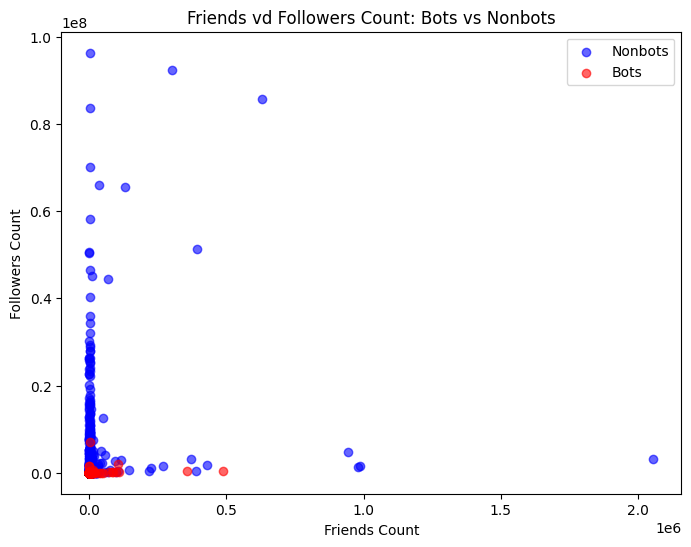

In [257]:
bots = df[df['bot'] == True]
nonbots = df[df['bot'] == False]

plt.figure(figsize=(8, 6))

plt.scatter(nonbots['friends_count'], nonbots['followers_count'], color = 'blue', alpha = 0.6, label = 'Nonbots')
plt.scatter(bots['friends_count'], bots['followers_count'], color = 'red', alpha = 0.6, label = 'Bots')

plt.xlabel('Friends Count')
plt.ylabel('Followers Count')
plt.title('Friends vd Followers Count: Bots vs Nonbots')

plt.legend()
plt.show()

In [258]:
bagWords = ['bot', 'follow me', 'free', 'fake', 'virus', 'troll', 'clone', 'tweet me']

def containsWord(text):
    if pd.isna(text):
        return False
    lowerText = text.lower()
    return any(word in lowerText for word in bagWords)

df['screen_name_binary'] = df['screen_name'].apply(containsWord)
df['name_binary'] = df['name'].apply(containsWord)
df['description_binary'] = df['description'].apply(containsWord)
df['status_binary'] = df['status'].apply(containsWord)

print(df[['screen_name', 'screen_name_binary', 'name', 'name_binary', 'description', 'description_binary', 'status', 'status_binary']].head())

        screen_name  ...  status_binary
0  "HoustonPokeMap"  ...          False
1         kernyeahx  ...          False
2   mattlieberisbot  ...           True
3         sc_papers  ...          False
4      lucarivera16  ...          False

[5 rows x 8 columns]


In [259]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.tree import export_text

subsetCols = ['friends_count', 'followers_count', 'screen_name_binary', 'name_binary', 'status_binary', 'verified', 'statuses_count', 'bot']
dfSubset = df[subsetCols].copy()
X = dfSubset.drop(columns = ['bot'])
Y = dfSubset['bot']

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size = 0.3)
clf = tree.DecisionTreeClassifier(criterion = 'entropy')
clf.fit(Xtrain, Ytrain)

trainAcc = accuracy_score(Ytrain, clf.predict(Xtrain))
testAcc = accuracy_score(Ytest, clf.predict(Xtest))

print(f"Training Accuracy: {trainAcc:.4f}")
print(f"Testing Accuracy: {testAcc:.4f}")

treeRules = export_text(clf, feature_names=X.columns)
print(treeRules)


Training Accuracy: 0.9989
Testing Accuracy: 0.8554
|--- verified <= 0.50
|   |--- friends_count <= 45.50
|   |   |--- statuses_count <= 61.00
|   |   |   |--- statuses_count <= 0.50
|   |   |   |   |--- followers_count <= 4.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- followers_count >  4.50
|   |   |   |   |   |--- followers_count <= 21.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- followers_count >  21.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- statuses_count >  0.50
|   |   |   |   |--- friends_count <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- friends_count >  0.50
|   |   |   |   |   |--- followers_count <= 8.50
|   |   |   |   |   |   |--- friends_count <= 27.50
|   |   |   |   |   |   |   |--- followers_count <= 7.00
|   |   |   |   |   |   |   |   |--- statuses_count <= 1.50
|   |   |   |   |   |   |   |   |   |--- friends_count <= 21.50
|   |   |   |   |   |   |   |   |   |   |--- followers_count <= 5.00
|   |  

In [260]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

clf.fit(Xtrain, Ytrain)
trainPred = clf.predict(Xtrain)
testPred = clf.predict(Xtest)

train_acc = accuracy_score(Ytrain, trainPred)
test_acc = accuracy_score(Ytest, testPred)

print(f"Training Accuracy (Logistic Regression): {train_acc:.4f}")
print(f"Testing Accuracy (Logistic Regression): {test_acc:.4f}")

Training Accuracy (Logistic Regression): 0.6973
Testing Accuracy (Logistic Regression): 0.6883


In [261]:
#Questions

#1. I don't think friends count and followers count is going to be enough to classify bots. Although, bots tend to have a lower followers and 
# friends count, there are many nonbots in the same vicinity who also have lower friends and follower counts

#2. If the model has a perfect training accuracy and a low testing accuracy, this represents overfitting. I ran my model a couple times and
# I had a high 90s training accuracy (a couple times it was perfect), but a testing accuracy sitting mid 80s. The test accuracy better represents
# the quality of the model because you can see how it performs on unseen data.

#3. The decision tree ran better for my dataset and had a higher testing accuracy. The logistic regression seems to be better in generalizing
# the data and could be useful if the data is more organized.

#4. This decision tree classified users using their verification and friends count. This model thinks the most informative features and their
# verification and friends count. These are the highest performing features that will help the bot decide.

df['bot'].value_counts(normalize = True)
#5. 46% of the total data were bots. This means our model performed well in determining whether or not a person was a bot. If only 10% of the
# data were bots, a 85% accuracy would not be good. This is because a model that always guesses nonbots would be 90% correct. To improve this
# we could use metrics like precision, recal, and f1 score to balance imbalances in our data.

#6. There could be problems with assigning the first 70% as training and the rest as test because our data could be sorted by age or some other
# variable. This means our bot won't have the patters of the metrics of older users in our data. An alternative could be to assign a random
# 70% if our data as training data and the rest and 30%. This would better capture the data and capture more patterns within our data.

#7. We were forced to use certain feautures in order to determine and bot like friends counts and verification. We were also instructed to use
# a decision tree. We also dropped columns as per the instructions. We were forced to use a specific training and test data split. We were 
# also told how to convert certain features like description to binary features. There's many different ways to handle all of these things.


bot
0    0.537425
1    0.462575
Name: proportion, dtype: float64

In [262]:
clf = tree.DecisionTreeClassifier(criterion = 'entropy', max_depth=2)
clf.fit(Xtrain, Ytrain)

trainAcc = accuracy_score(Ytrain, clf.predict(Xtrain))
testAcc = accuracy_score(Ytest, clf.predict(Xtest))

print(f"Training Accuracy: {trainAcc:.4f}")
print(f"Testing Accuracy: {testAcc:.4f}")

treeRules = export_text(clf, feature_names=X.columns)
print(treeRules)

Training Accuracy: 0.7845
Testing Accuracy: 0.7955
|--- verified <= 0.50
|   |--- friends_count <= 45.50
|   |   |--- class: 1
|   |--- friends_count >  45.50
|   |   |--- class: 0
|--- verified >  0.50
|   |--- statuses_count <= 6053.00
|   |   |--- class: 0
|   |--- statuses_count >  6053.00
|   |   |--- class: 0



In [263]:
import random

X1s =  []
X2s = []
Ys = []

for x in range(1000):
    x1 = random.random()
    x2 = random.random()
    
    X1s.append(x1)
    X2s.append(x2)
    
    Y = 1 if x1 + x2 > 1 else 0
    Ys.append(Y)
    
df = pd.DataFrame(data={"X1": X1s, "X2": X2s, "Y": Ys})

df.head()


,X1,X2,Y
0,0.279650,0.431010,0
1,0.016790,0.067137,0
2,0.521430,0.633692,1
3,0.095344,0.137329,0
4,0.955516,0.627618,1


Text(0.5, 1.0, 'Scatterplot of Ys (0 or 1)')

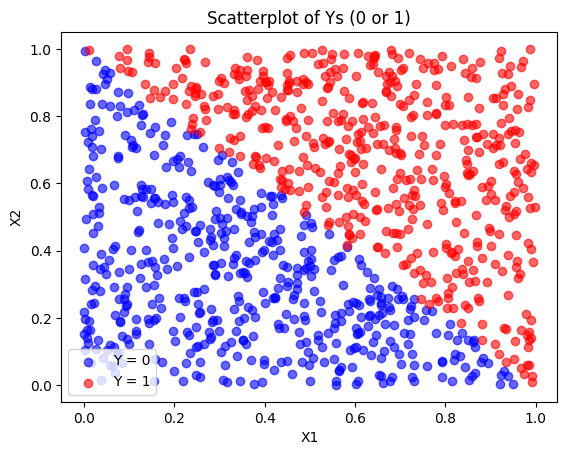

In [264]:
plt.scatter(df[df["Y"] == 0]["X1"], df[df['Y'] == 0]["X2"], color="blue", label="Y = 0", alpha= 0.6)
plt.scatter(df[df["Y"] == 1]["X1"], df[df['Y'] == 1]["X2"], color="red", label="Y = 1", alpha= 0.6)

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("Scatterplot of Ys (0 or 1)")

In [265]:
X = df[["X1", "X2"]]
Y = df["Y"]

clf = DecisionTreeClassifier(criterion="entropy", max_depth=2)
clf.fit(X, Y)

pred = clf.predict(X)
acc = accuracy_score(Y, pred)
print(f"Decision Tree Accuracy (max_depth=2): {acc:.4f}")

clf2 = LogisticRegression(max_iter=1000)
clf2.fit(X, Y)

pred2 = clf2.predict(X)
acc2 = accuracy_score(Y, pred2)
print(f"Logistic Regression Accuracy: {acc2:.4f}")

Decision Tree Accuracy (max_depth=2): 0.8200
Logistic Regression Accuracy: 0.9890


In [ ]:
#2 Questions

#1. There is a perfect line where Y is 1 when X1 + X2 > 1. This is why we should expect 100%. My model is floating around high 99% probably
# because of rounding.

#2. The accuracy of my decision tree classifier sits just below 90%.

clf = DecisionTreeClassifier(criterion="entropy")
clf.fit(X, Y)

pred = clf.predict(X)
acc = accuracy_score(Y, pred)
print(f"Accuracy Score with no max_depth: {acc:.4f}")
#3. Now the accuracy of the decision tree classifier is 100%

#4. The boundary is exactly the line x1 + x2 = 1. The decision tree is creating step like approximations around that line in order to get the
# data to be perfect. This is a form of overfitting since the model isn't generalizing the data. 

Accuracy Score with no max_depth: 1.0000
